# Stage 5: severity and burning cost (D031-D033)

Display only. Run `make all` first; this notebook reads `reports/`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from src.config import load_config

cfg = load_config()
T, F = cfg["paths"]["tables"], cfg["paths"]["figures"]
pd.set_option("display.width", 200)


def show(name):
    plt.figure(figsize=(12, 5))
    plt.imshow(mpimg.imread(F / name))
    plt.axis("off")
    plt.show()

In [2]:
pd.read_csv(T / "severity_selection_log.csv")

,step,factor,cv_deviance_mean,improvement_mean,improvement_sd,folds_improved,relative_improvement,share_levels_ci_excludes_1,passes_cv,passes
0,1,DrivAge_band,1.037850,0.000196,0.003909,2,0.000189,0.300000,False,False
1,1,VehAge_band,1.036990,0.001056,0.004697,3,0.001017,0.500000,False,False
2,1,VehPower_band,1.039572,-0.001527,0.001095,0,-0.001471,0.000000,False,False
3,1,BonusMalus_band,1.036371,0.001675,0.000875,5,0.001613,0.300000,True,False
4,1,LogDensity_band,1.038675,-0.000630,0.001911,2,-0.000607,0.125000,False,False
5,1,VehBrand_grp,1.040404,-0.002358,0.004483,2,-0.002271,0.111111,False,False
6,1,Region_grp,1.037157,0.000889,0.004647,2,0.000856,0.117647,False,False
7,1,VehGas,1.038154,-0.000108,0.000140,1,-0.000104,0.000000,False,False
8,1,BonusMalus_sev3,1.036239,0.001807,0.000778,5,0.001741,1.000000,True,True
9,2,DrivAge_band,1.037282,-0.001044,0.002887,2,-0.001007,0.200000,False,False


In [3]:
pd.read_csv(T / "severity_model_comparison.csv")

,model,factors,n_params,cv_gamma_deviance_mean,cv_gamma_deviance_sd,holdout_gamma_deviance,dispersion
0,Severity intercept only,NaN,1,1.038046,0.038359,0.987231,2.316462
1,Severity GLM,BonusMalus_sev3,3,1.036239,0.038337,0.986332,2.307130


In [4]:
pd.read_csv(T / "severity_residual_summary.csv")

,dataset,policies,claims,share_policies_single_fixed_amount_claim,deviance_residual_mean,deviance_residual_sd,deviance_residual_skew,share_abs_residual_gt_3,residual_mean_fixed_amount_policies,residual_mean_other_policies,calibration_ae_min,calibration_ae_max,fixed_amounts_used
0,learn_oof,19893,21071,0.358619,-0.346262,0.988653,1.285107,0.016388,-0.299191,-0.372581,0.947065,1.045836,1204.00; 1128.12; 1172.00
1,holdout,5051,5373,0.362700,-0.348421,0.963231,1.332948,0.015640,-0.298828,-0.376645,0.866845,1.086053,1204.00; 1128.12; 1172.00


In [5]:
pd.read_csv(T / "burning_cost_reconciliation.csv")

,frequency_model,large_loss_load,dataset,policies,modelled_burning_cost,actual_losses,actual_over_modelled,actual_attritional,modelled_attritional,actual_claims,modelled_claims
0,GLM-A,0.335891,learn,541840,4.518503e+07,45216079.76,1.000687,33847128.96,3.382388e+07,21071.0,21056.000000
1,GLM-A,0.335891,holdout,136151,1.127108e+07,14693136.74,1.303614,8508040.58,8.437126e+06,5373.0,5254.812390
2,GLM-A,0.335891,holdout excl. largest claim,136150,1.127093e+07,10617736.18,0.942046,8488040.58,8.437013e+06,5372.0,5254.749517
3,GLM-B,0.335891,learn,541840,4.518503e+07,45216079.76,1.000687,33847128.96,3.382388e+07,21071.0,21056.000000
4,GLM-B,0.335891,holdout,136151,1.127466e+07,14693136.74,1.303200,8508040.58,8.439806e+06,5373.0,5256.399873
5,GLM-B,0.335891,holdout excl. largest claim,136150,1.127449e+07,10617736.18,0.941749,8488040.58,8.439675e+06,5372.0,5256.327162


In [6]:
pd.read_csv(T / "large_loss_sensitivity.csv")

,threshold,learn_claims_above,large_loss_load,load_min_across_folds,load_max_across_folds,share_of_burning_cost_in_flat_load,holdout_attritional_actual_over_modelled
0,10000,388,0.442281,0.235489,0.601086,0.306654,1.005850
1,20000,170,0.335891,0.158462,0.496856,0.251436,1.008085
2,50000,66,0.222789,0.102004,0.399381,0.182198,1.021242


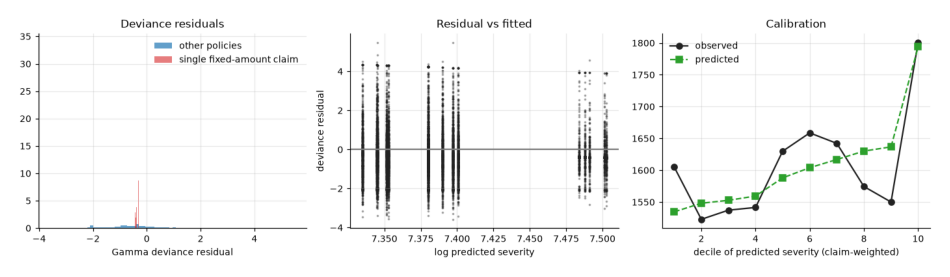

In [7]:
show("severity_residuals_learn_oof.png")